# Probabilistic error cancelation with logical noise models

<p align="center">
<img src="images/hex-ising.png" width="415"/>
</p>

In this tutorial we will evaluate observables of a ``22``-site Ising model on a ***hexagonal*** lattice using a Heron QPU, which has a ***heavy-hexagonal*** qubit topology. Many demonstrations on Heron QPUs focus on systems defined on heavy-hexagonal lattices to match the system's connectivity; however, hexagonal models tend to be more interesting to study as they appear more commonly in nature and are more difficult to simulate classically due to their denser connectivity. Since the qubit topology of the QPU cannot directly support the connectivity of a hexagonal lattice, we must decide how to efficiently embed the hexagonal model onto the qubit topology. In this example we represent each site in the Ising model with a qubit lying on a vertex of the heavy-hex QPU lattice. We use the qubits on the edges (***mediator qubits***) to facilitate entanglement between the Ising qubits on the vertices. Additionally, the mediator qubits implement entanglement in such a way that they are always expected to return to the ground state $|0\rangle$. If a mediator qubit measures $|1\rangle$, it indicates a logical error occured during circuit execution; postselecting only samples with no detected errors on the mediator qubits yields a smaller distribution of ***logical samples*** which may have a higher fidelity than the raw, noisy distribution. Not only can we detect that an error occurred by measuring a mediator qubit, we can also determine exactly which logical errors that qubit is capable of detecting throughout the circuit. Removing the noise generators the mediator qubits' ***symmetry checks*** are capable of detecting from a noise model leaves a reduced noise model, which can be mitigated using techniques such as probabilistic error cancellation (PEC).

In this notebook example, we will combine the error detection technique described above with PEC to counteract the quantum noise more effectively than either technique can do alone. We will use ``49`` qubits to embed the ``22``-qubit Ising model and use the extra ``27`` mediator qubits for error detection. We will run PEC on the postselected noise channel to mitigate the noise that evades the symmetry checks. In addition to combining error detection with PEC, we will use techniques such as TREX readout error mitigation and non-Markovian error checks to further combat the effect of quantum noise.

The workflow will be as follows:
1. Classically simulate observable expectation values for the ``22``-qubit hex-Ising model
2. Implement the ``49``-qubit error-detecting hex-Ising model with a quantum circuit and transpile to QPU backend
3. Specify the entangling layers in the circuit with ``samplomatic``. We will learn and mitigate the noise affecting these entangling layers.
4. Add non-Markovian error checks to the circuit
5. Learn the gate and readout noise affecting the circuit
6. Prune the noise model of terms detected by the symmetry checks
7. Sample the error-detecting circuit. Postselect only samples that pass all symmetry and non-Markovian error checks, and use TREX readout mitigation for all expectation value calculations.
    - Sample the error-detecting circuit
    - Sample the error-detecting circuit with PEC, but do not postselect based on symmetry checks and mitigate the full learned noise channel.
    - Sample the error-detecting circuit with PEC. Postselect based on symmetry checks and only mitigate the noise that is undetectable by the checks.
8. Calculate expectation values and compare strategies. Observe that QED+PEC more effectively cancels the noise affecting the experiment than either method on its own and produces converged expectation values using far fewer shots than required by PEC alone.

**Note:** by default this notebook renders every figure from the saved results file that accompanies it, so it can be run without QPU access. Set ``RUN_MITIGATION_ON_HARDWARE = True`` to rerun the full experiment on hardware and overwrite the saved data.

### Classically simulate $\langle X \rangle_i$ for each site in the 22-qubit hex-Ising model

First, we use Qiskit's ``Statevector`` class to simulate the exact target values for our experiment. While the 22-qubit problem we're solving is tractable classically, Qiskit's statevector simulator will not scale to demos much larger than this one, and to scale up past ``50`` qubits or so, one would need to use inexact simulation techniques, such as [Pauli propagation](https://qiskit.github.io/pauli-prop/). This ``49``-qubit experiment allows us to investigate combining error detection with error mitigation at larger scales while maintaining access to the ideal expectation values.

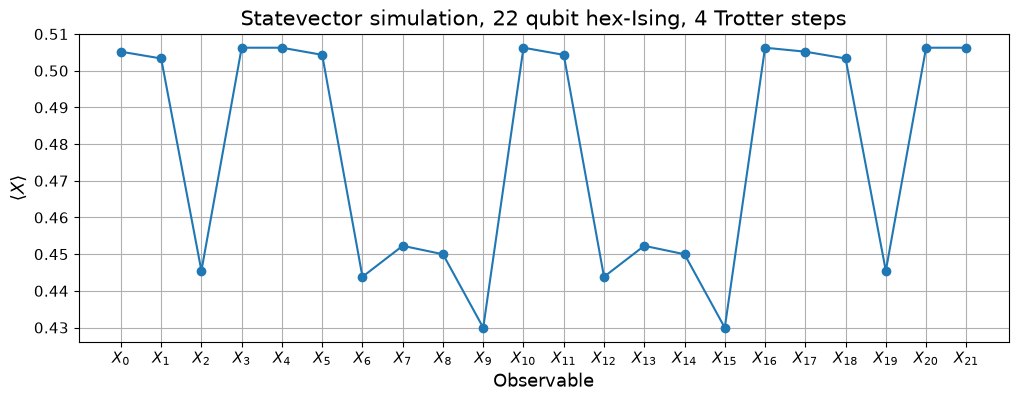

In [1]:
import networkx as nx
import numpy as np
import visualization as viz
from qiskit.circuit import QuantumCircuit
from qiskit.quantum_info import Statevector, Pauli

# Hexagonal lattice
data_graph = nx.convert_node_labels_to_integers(nx.hexagonal_lattice_graph(2, 3))

# Number of Trotter steps and rotation angles
depth = 4
zz_coeff = -np.pi / 4
x_coeff = 3 * np.pi / 8
n_data = data_graph.order()
n_checks = data_graph.size()
n_qubits = n_data + n_checks

qc_data = QuantumCircuit(n_data)
qc_data.h(range(n_data))
for _ in range(depth):
    for edge in data_graph.edges:
        qc_data.rzz(zz_coeff, *edge)
    qc_data.rx(x_coeff, range(n_data))
psi_exact = Statevector(qc_data)

# X on site i = qubit i
observables = ["I" * (n_data - 1 - i) + "X" + "I" * i for i in range(n_data)]
obs_exact = [psi_exact.expectation_value(Pauli(o)).real for o in observables]

viz.plot_exact(
    obs_exact,
    viz.x_labels(range(n_data), n_data),
    f"Statevector simulation, {n_data} qubit hex-Ising, {depth} Trotter steps",
)

### Implement the ``49``-qubit error-detecting hex-Ising model with a quantum circuit and transpile to QPU backend

This circuit simulates ``4`` Trotter steps of a ``22``-qubit transverse-field Ising Hamiltonian on a hexagonal lattice. The ``22`` data qubits are embedded in a ``49``-qubit heavy-hex subgraph of the Heron r3 QPU, ``ibm_boston``. The ``27`` ancilla qubits are used for two purposes: mediating entanglement between the Ising qubits and detecting logical errors during circuit execution. The circuit's entangling layers are implemented such that the mediator qubits return to the ground state $|0\rangle$ before their terminal measurements. One or more mediator qubits measuring $|1\rangle$ indicates that sample was corrupted by a logical error. Discarding these samples can improve the fidelity of the sampled distribution.

In the graph below, the green qubits represent the ``22`` Ising qubits, and the orange qubits represent the ``27`` mediator qubits.

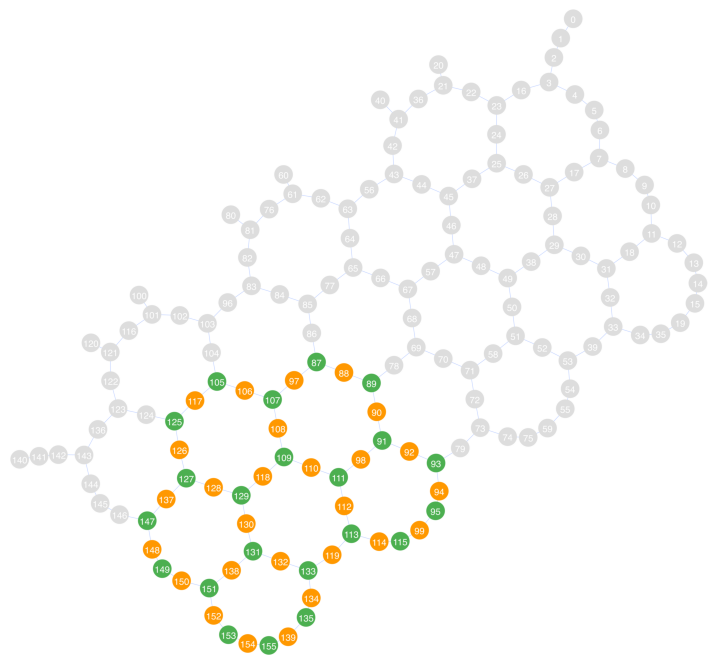

In [2]:
from qiskit.circuit import ClassicalRegister
from qiskit.transpiler import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService

backend_name = "ibm_boston"


def generate_ed_ising(graph, depth, zz_coeff, x_coeff):
    """Build the mediated error-detecting Ising circuit for data-qubit `graph`; returns (circuit, CZ layers, hardware graph)."""
    hw_graph = nx.Graph()
    for i, (a, b) in enumerate(graph.edges()):
        hw_graph.add_edges_from([(a, i + graph.order()), (b, i + graph.order())])
    coloring = nx.coloring.greedy_color(nx.line_graph(hw_graph), strategy="DSATUR")
    layers_coupling = [[e for e, c in coloring.items() if c == i] for i in set(coloring.values())]
    circuit = QuantumCircuit(hw_graph.order())
    circuit.h(range(hw_graph.order()))
    for _ in range(depth):
        for angle, qubits in (
            (zz_coeff, range(graph.order(), hw_graph.order())),
            (x_coeff, range(graph.order())),
        ):
            circuit.barrier()
            for layer in layers_coupling:
                for edge in layer:
                    circuit.cz(*edge)
            circuit.barrier()
            circuit.rx(angle, qubits)
    circuit.barrier()
    circuit.h(range(graph.order(), hw_graph.order()))
    return circuit, layers_coupling, hw_graph


service = QiskitRuntimeService()
backend = service.backend(backend_name, calibration_id="extra_gates")  # includes xslow

circuit, layers_coupling, hw_graph = generate_ed_ising(data_graph, depth, zz_coeff, x_coeff)

circ_meas = circuit.copy()
data_reg, check_reg = ClassicalRegister(n_data, "data"), ClassicalRegister(n_checks, "check")
circ_meas.add_register(data_reg, check_reg)
circ_meas.barrier()
circ_meas.measure(range(n_data), data_reg)
circ_meas.measure(range(n_data, n_qubits), check_reg)

# Physical qubits hosting the 22 Ising sites on ibm_boston, one heavy-hex row per lattice chain;
# the mediator for each edge is the physical qubit sitting between its two data qubits
data_layout = [
    *[95, 93, 91, 89, 87],
    *[115, 113, 111, 109, 107, 105],
    *[135, 133, 131, 129, 127, 125],
    *[155, 153, 151, 149, 147],
]
coupling_graph = nx.Graph(list(backend.coupling_map.get_edges()))
layout = data_layout + [
    next(iter(nx.common_neighbors(coupling_graph, data_layout[a], data_layout[b])))
    for a, b in data_graph.edges()
]

circ_trans = generate_preset_pass_manager(
    backend=backend, optimization_level=1, initial_layout=layout
).run(circ_meas)

viz.plot_layout(backend, layout, n_data)

### Specify the entangling layers in the circuit with ``samplomatic``.

Samplomatic's ``generate_boxing_pass_manager`` pass groups the circuit's entangling layers into annotated boxes for Pauli twirling and PEC noise injection. The resulting template circuit and samplex (a parametric distribution over the template circuit specifying its twirls and noise injection) are used to define and execute all of the noise learning and sampling QPU experiments. The measurement boxes also carry a ``ChangeBasis`` annotation, so the rotations that measure the data qubits in the X basis are supplied to the samplex as an input at sampling time rather than being baked into the circuit.

Below, the same boxing pass is applied to a tiny version of the error-detecting Ising circuit so we can visualize the structure of a boxed circuit.

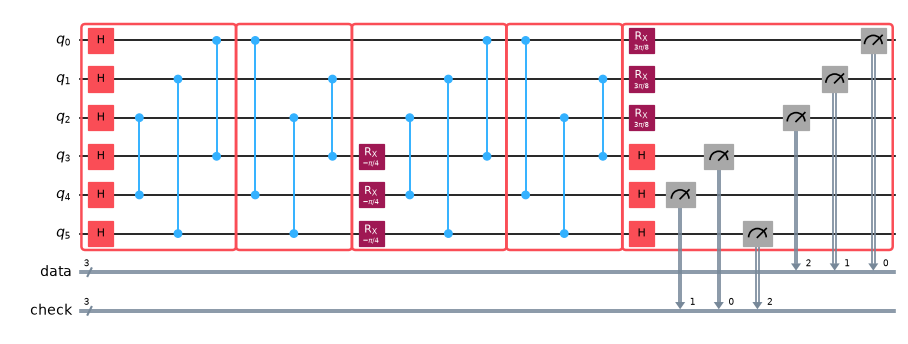

In [3]:
from samplomatic.builders import build
from samplomatic.transpiler import generate_boxing_pass_manager
from samplomatic.utils import find_unique_box_instructions

mit_file = f"ising_ed_pec_ieee_mitigation_{backend_name.removeprefix('ibm_')}.npz"
RUN_MITIGATION_ON_HARDWARE = False  # True: rerun the session and overwrite the saved data

if RUN_MITIGATION_ON_HARDWARE:
    boxed = generate_boxing_pass_manager(
        enable_gates=True,
        enable_measures=True,
        inject_noise_targets="gates",
        inject_noise_strategy="individual_modification",
        inject_noise_site="after",
        twirling_strategy="active_circuit",
        measure_annotations="all",
    ).run(circ_trans)
    template, samplex = build(boxed)
    unique_instructions = find_unique_box_instructions(
        boxed, normalize_annotations=None, undress_boxes=True
    )

    # Measure X on the data qubits and Z on the mediators
    basis_key = next(
        s.name for s in samplex.inputs().get_specs() if s.name.startswith("basis_changes.")
    )
    meas_basis = np.array(
        [2 if q in set(layout[:n_data]) else 1 for q in sorted(layout)], dtype=np.uint8
    )

viz.draw_toy_circuit(generate_ed_ising, zz_coeff, x_coeff, include_checks=False)

### Add non-Markovian error checks to the circuit

Next, we add [non-Markovian error checks](https://github.com/Qiskit/qiskit-mitigation/blob/main/docs/guides/postselection_with_non_markovian_error_checks.ipynb) to the circuit in order to protect against noise that isn't modeled in our learning protocol. These checks work by implementing a long-pulse bit-flip and ensuring the qubit correctly moved from one classical state to another. If both qubits on an edge fail the check, the sample is discarded. Non-Markovian error checks can be used at the beginning or end of the circuit (or both); here we use them only at the end. We also place checks on unused "spectator" qubits adjacent to the circuit, providing more coverage against the noise these checks are designed to detect.

Remember, similar to symmetry checks, this is also a form of postselection, so we need to ensure we are accounting for the drop in postselection rate when combining these techniques. Concretely, if $P(\text{non-Markovian error}) = \alpha$ and $P(\text{symmetry error}) = \beta$, then you need approximately $\frac{1}{(1-\alpha)(1-\beta)}$ noisy samples to recover one logical sample.

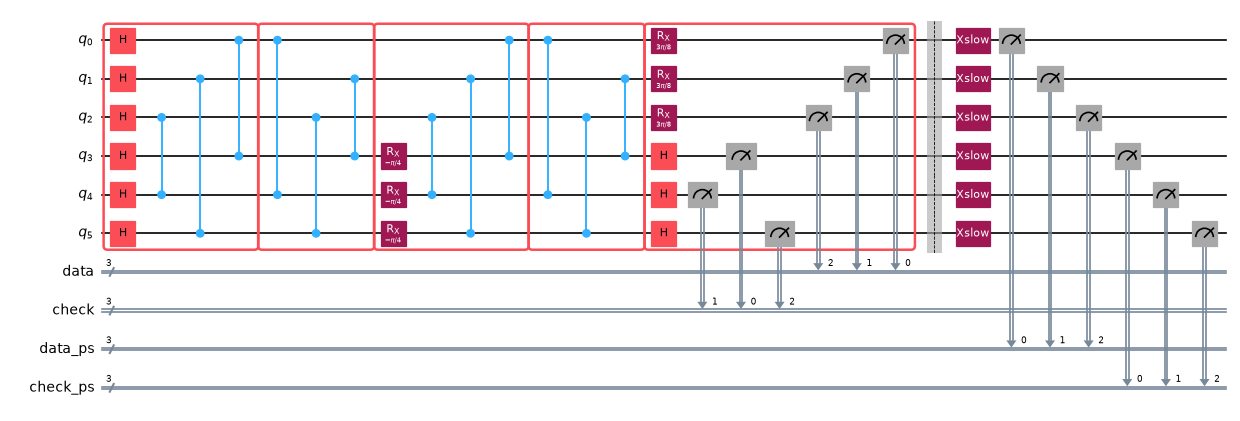

In [4]:
from qiskit.transpiler import PassManager
from qiskit_mitigation.postselection import PostSelector
from qiskit_mitigation.postselection.passes import (
    AddPostCircuitNonMarkovianErrorChecks,
    AddSpectatorPostCircuitNonMarkovianErrorChecks,
)

if RUN_MITIGATION_ON_HARDWARE:
    add_checks = PassManager(
        [
            AddPostCircuitNonMarkovianErrorChecks(x_pulse_type="xslow"),
            AddSpectatorPostCircuitNonMarkovianErrorChecks(backend.coupling_map, x_pulse_type="xslow"),
        ]
    )
    template_checked = add_checks.run(template)
    selector = PostSelector.from_circuit(template_checked, backend.coupling_map)

viz.draw_toy_circuit(generate_ed_ising, zz_coeff, x_coeff, include_checks=True)

### Learn the gate and readout noise for the 49-qubit checked-Ising circuit.

To mitigate the noise, we must model how the noise is affecting our entangling gates. Here we learn a Pauli-Lindblad noise model for each of the circuit's 3 unique entangling layers using [qiskit-noise-learning](https://github.com/Qiskit/qiskit-noise-learning). Later, we will prune this noise model of error generators that are detectable by the symmetry checks and mitigate only the remaining noise channel with PEC. The map below shows the three learned layers on the QPU; each qubit is a wheel of its weight-1 X/Y/Z rates, and each coupler a 3×3 grid of the weight-2 Pauli rates on that pair. The $\gamma$ value of $10$ implies a sampling overhead of $\gamma^2=10^2=100$.

The readout (TREX) corrections come directly from the SPAM paths of the noise-learning fit. The stem plot below the QPU noise map shows the per-observable TREX rescale factors.

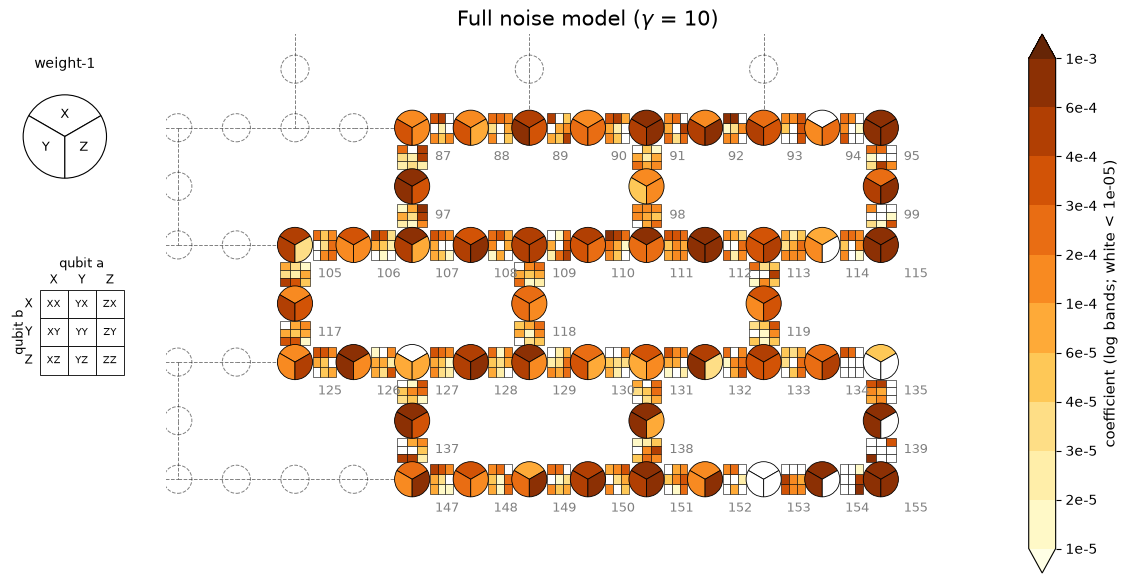

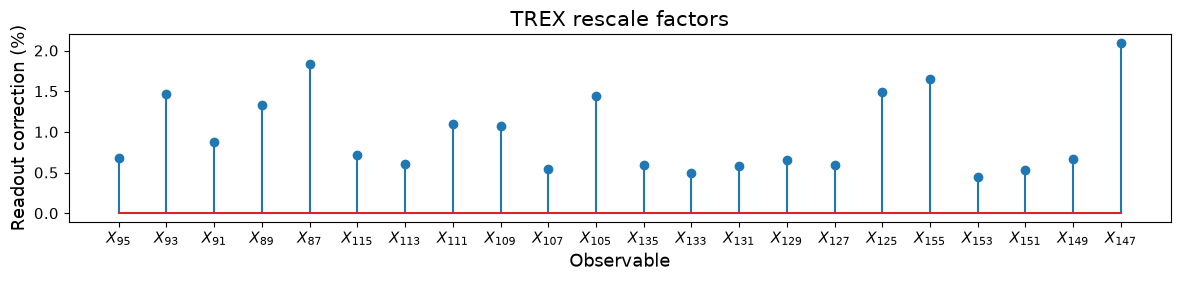

In [5]:
from qiskit.quantum_info import QubitSparsePauli
from qiskit_ibm_runtime import Executor, Session
from qiskit_ibm_runtime.quantum_program import QuantumProgram
from qiskit_mitigation.trex import TREX
from qiskit_noise_learning.analysis import (
    ComputeObservables,
    CurveFitObservables,
    FlipPostSelect,
    LeastSquaresSolve,
)
from qiskit_noise_learning.circuit_generator import ExecutorCircuitGenerator
from qiskit_noise_learning.experiment_builder import (
    BindFragmentDepths,
    CompleteSequences,
    EvenDepthVanillaPaths,
    Experiment,
    GenerateInstructionSequences,
    IdentifyRelations,
    MergeInstructionSequences,
    SPAMPaths,
    VanillaInstructionSequences,
)
from qiskit_noise_learning.gate_sets import QiskitGateSet
from qiskit_noise_learning.models import PauliLindbladModel
from samplomatic.annotations import InjectNoise
from samplomatic.utils import get_annotation

if RUN_MITIGATION_ON_HARDWARE:
    gate_set = QiskitGateSet(
        target=backend.target,
        qubit_subset=sorted(
            {boxed.find_bit(q).index for i in unique_instructions for q in i.qubits}
        ),
    )
    ref_to_qubits = {}
    for inst in unique_instructions:
        if ann := get_annotation(inst.operation, InjectNoise):
            gate_set.add_box_as_gate(inst, name=ann.ref)
            ref_to_qubits[ann.ref] = sorted(boxed.find_bit(q).index for q in inst.qubits)

    fidelity_model = PauliLindbladModel.k_local(
        gate_set, gate_k={**{r: 2 for r in ref_to_qubits}, "M": 1, "P": 1}
    )
    experiment = (
        EvenDepthVanillaPaths()
        + VanillaInstructionSequences()
        + IdentifyRelations()
        + SPAMPaths()
        + GenerateInstructionSequences()
        + MergeInstructionSequences()
        + CompleteSequences()
        + BindFragmentDepths([2, 4, 8, 12])
    ).run(Experiment(fidelity_model=fidelity_model, shots=384, randomizations=64))

    circuit_generator = ExecutorCircuitGenerator(gate_set, pass_manager=add_checks)
    program_learn, data_mapper = circuit_generator.generate(experiment)

    session = Session(backend)
    fit = circuit_generator.collect(Executor(session).run(program_learn).result(), data_mapper)
    fit = (FlipPostSelect() + ComputeObservables() + CurveFitObservables() + LeastSquaresSolve()).run(fit)
    print(
        "learning shots removed by checks:",
        f"{float(fit.raw_data.datatree['0']['data_mask'].mean()):.4f}",
    )

    # TREX factors from the fit's SPAM paths: the fit only identifies the product of
    # state-prep and measurement error, so hand TREX the composition of the two maps
    spam = fidelity_model.to_pauli_lindblad_maps(fit.model_data, include_spam=True)
    spam_map = spam["P"].compose(spam["M"])
    z_terms = [
        QubitSparsePauli(("Z", [layout[i]]), num_qubits=backend.num_qubits) for i in range(n_data)
    ]
    trex_rescale = np.array([TREX.calculate_trex_factor(spam_map, z) for z in z_terms])

if not RUN_MITIGATION_ON_HARDWARE:
    viz.draw_noise_map(np.load(mit_file), backend)
    viz.plot_trex(np.load(mit_file)["trex_rescale"], viz.x_labels(layout, n_data))

### Prune the noise model of terms detectable by the symmetry checks

Each symmetry check is capable of detecting some subset of error generators in the noise model, which means that you don't need to mitigate those errors. Here we create a mask over the detectable noise generators using the ``create_postselected_noise_mask`` function from ``qiskit_mitigation``. This mask will be used to prune the noise model of detectable terms before performing PEC. Performing PEC with respect to the pruned noise model can yield converged expectation values for a fraction of the sampling cost required to perform PEC on the full noise model, as illustrated in the noise model maps above.

The map below is drawn on the same color scale as the learned model above, keeping only the error generators the checks cannot detect. We see that a large number of error generators have been removed from the model, and the sampling overhead has dropped significantly. The sampling overhead to run PEC on the pruned noise model is $\gamma^2=2.5^2\approx6.3$ -- roughly a 16x reduction from the overhead required to mitigate the full noise channel.

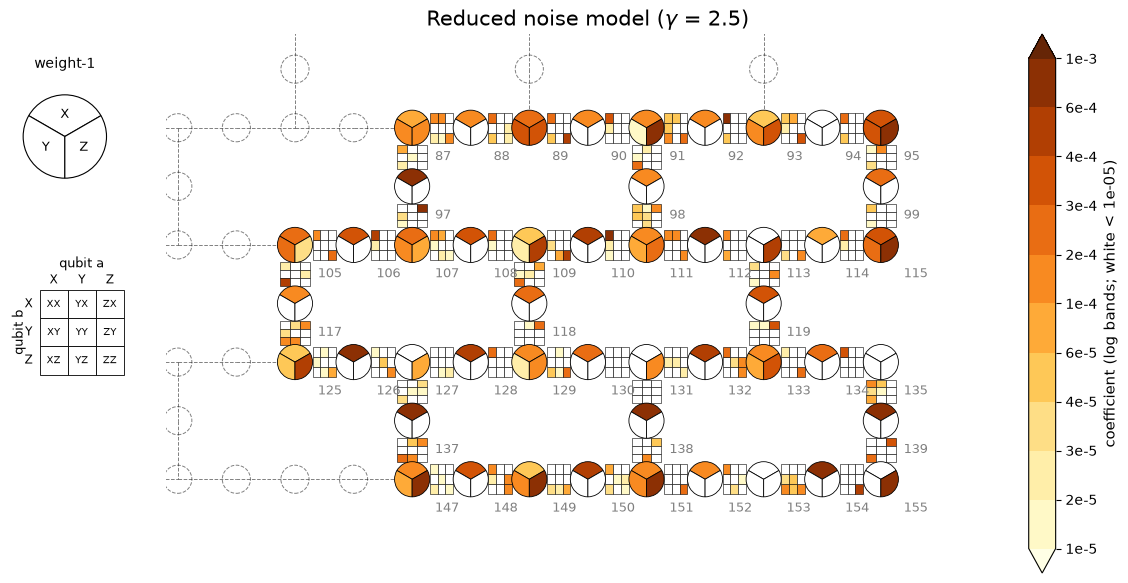

In [6]:
from qiskit.quantum_info import Pauli, PauliLindbladMap
from qiskit_mitigation.noise import create_postselected_noise_mask
from qiskit_noise_learning.models.utils import split_pauli_lindblad_model

SHOTS_PER_RAND = 64  # shots per PEC randomization
N_RAND = 23_054  # PEC randomizations per experiment
MAX_PAIR_RATE = 0.02  # Max value of any coupler's summed two-qubit error rate

if RUN_MITIGATION_ON_HARDWARE:
    # learned maps come back in backend qubit indexing; samplex wants box-local order
    plm = split_pauli_lindblad_model(fit.model).model
    noise_maps = {}
    for ref, m in plm.to_pauli_lindblad_maps(fit.model_data).items():
        box = ref_to_qubits[ref]
        noise_maps[ref] = PauliLindbladMap.from_sparse_list(
            [(p, tuple(box.index(q) for q in qs), r) for p, qs, r in m.to_sparse_list()],
            num_qubits=len(box),
        )

    # The detectors are virtual Pauli-Z's representing the measurements on the mediator qubits
    # We can find the set of detectable noise generators in the model for each detector by conjugating
    # it backward through the circuit and calculating what generators it anti-commutes with.
    detectors = [Pauli("I" * (boxed.num_qubits - 1 - q) + "Z" + "I" * q) for q in layout[n_data:]]
    # Detectable generators are handled by postselection; prune them from the model for PEC
    local_scales, gamma2_post = create_postselected_noise_mask(boxed, noise_maps, detectors)
    gamma_post = gamma2_post**0.5
    # Full-PEC cost: each learned layer acts twice per Trotter step (compute + uncompute)
    gamma = float(np.exp(2 * depth * sum(2 * sum(m.rates) for m in noise_maps.values())))
    print(f"gamma PEC {gamma:.2f} | gamma QED+PEC {gamma_post:.2f}")

    # Kill the job if any coupler's summed rate exceeds MAX_PAIR_RATE
    pair_lam = {}
    for m in noise_maps.values():
        for _, qs, r in m.to_sparse_list():
            if len(qs) == 2:
                pair_lam[tuple(sorted(qs))] = pair_lam.get(tuple(sorted(qs)), 0.0) + r
    assert max(pair_lam.values()) < MAX_PAIR_RATE, (
        f"kill: degraded coupler {max(pair_lam, key=pair_lam.get)}"
    )

if not RUN_MITIGATION_ON_HARDWARE:
    viz.draw_noise_map(np.load(mit_file), backend, reduced=True)

### Sample the error detecting circuit

Here we sample the ``49``-qubit error-detecting Ising circuit. We enable Pauli twirling and non-Markovian error checks, but we do not perform PEC sampling. We will use these samples to calculate baseline expectation values as well as error-detection-only expectation values.

In [7]:
if RUN_MITIGATION_ON_HARDWARE:
    # Baseline = the ED+PEC template itself at noise scale 0, i.e. twirling only
    program_tw = QuantumProgram(shots=100)
    program_tw.append_samplex_item(
        template_checked,
        samplex=samplex,
        shape=(1000, 1),
        samplex_arguments={
            "pauli_lindblad_maps": dict(noise_maps),
            basis_key: meas_basis,
            **{f"noise_scales.{k}": 0.0 for k in local_scales},
        },
    )
    job_tw = Executor(session).run(program_tw)

### Sample the error-detecting circuit with PEC

Now we sample again and include PEC randomizations to mitigate the noise the symmetry checks can't detect. These samples will be used to calculate expectation values using error detection in combination with PEC. Below we plot the accepted shots per PEC randomization against a binomial at the mean acceptance rate. We see that acceptance is uncorrelated with the sampled circuit instance because QED+PEC injects only undetectable Paulis, which commute with the measurements of every mediator qubit.

In [8]:
if RUN_MITIGATION_ON_HARDWARE:

    def launch(session, template, samplex, samplex_args, n_rand, shots_per_rand):
        """Sample `n_rand` randomizations of `template` on `session` in <=100k-randomization jobs; returns the jobs."""
        jobs = []
        for start in range(0, n_rand, 100_000):
            program = QuantumProgram(shots=shots_per_rand)
            program.append_samplex_item(
                template,
                samplex=samplex,
                samplex_arguments=samplex_args,
                shape=(min(100_000, n_rand - start), 1),
            )
            jobs.append(Executor(session).run(program))
        return jobs

    # Reduced PEC
    args_post = {
        "pauli_lindblad_maps": dict(noise_maps),
        basis_key: meas_basis,
        **{f"noise_scales.{k}": -1.0 for k in local_scales},
        **{f"local_scales.{k}": v for k, v in local_scales.items()},
    }
    # PEC on the full noise model
    args_van = {
        "pauli_lindblad_maps": dict(noise_maps),
        basis_key: meas_basis,
        **{f"noise_scales.{k}": -1.0 for k in local_scales},
    }

    # Run sampling jobs
    jobs = launch(session, template_checked, samplex, args_post, N_RAND, SHOTS_PER_RAND)
    jobs_van = launch(session, template_checked, samplex, args_van, N_RAND, SHOTS_PER_RAND)
    outs = [j.result()[0] for j in jobs]
    outs_van = [j.result()[0] for j in jobs_van]
    (out_tw,) = job_tw.result()
    session.close()

Save hardware data and visualize that PEC randomizations commute with the measurements on the mediator qubits and do not affect the postselection statistics.

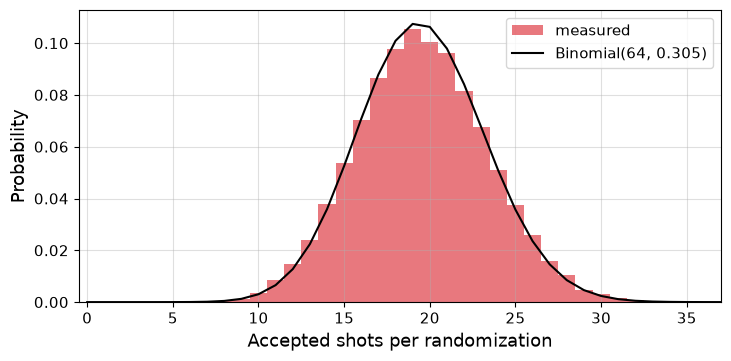

In [9]:
if RUN_MITIGATION_ON_HARDWARE:

    def bitflip_mask(out, selector):
        """Per-shot True/False for job result `out`: shot passes `selector`'s non-Markovian error checks."""
        regs = {
            k: np.asarray(out[k])
            for k in out
            if not k.startswith(("measurement_flips", "pauli_signs"))
        }
        return selector.compute_mask(regs, "edge", mode="post")

    def symmetry_mask(out):
        """Per-shot True/False for job result `out`: every twirl-corrected symmetry check reads 0."""
        return ~(np.asarray(out["check"]) ^ np.asarray(out["measurement_flips.check"])).any(axis=-1)

    def keep_mask(out, selector):
        """Per-shot True/False for job result `out`: shot passes both check types."""
        return symmetry_mask(out) & bitflip_mask(out, selector)

    def fracs(out_list, selector):
        """Fractions of shots across the job results in `out_list` passing [no, non-Markovian error, symmetry, both] checks."""
        bf = np.concatenate([bitflip_mask(o, selector) for o in out_list])
        sy = np.concatenate([symmetry_mask(o) for o in out_list])
        return [1.0, bf.mean(), sy.mean(), (bf & sy).mean()]

    mask_post = np.concatenate([keep_mask(o, selector) for o in outs])

    # Save experiment data to disk
    site_ref = {
        a.modifier_ref: a.ref
        for inst in boxed.data
        if inst.operation.name == "box"
        and (a := get_annotation(inst.operation, InjectNoise))
        and a.ref
    }
    sites = sorted(local_scales, key=lambda s: int(s[1:]))
    saved = dict(
        **{f"rates_{i}": np.asarray(m.rates) for i, m in enumerate(noise_maps.values())},
        **{
            f"label_paulis_{i}": [p for p, _, _ in m.to_sparse_list()]
            for i, m in enumerate(noise_maps.values())
        },
        **{
            f"label_qubits_{i}": [
                list(qs) + [-1] * (2 - len(qs)) for _, qs, _ in m.to_sparse_list()
            ]
            for i, m in enumerate(noise_maps.values())
        },
        layout=layout,
        site_scales=np.stack([local_scales[s] for s in sites]),
        site_layer=[list(noise_maps).index(site_ref[s]) for s in sites],
        ps_fracs=[fracs([out_tw], selector), fracs(outs_van, selector), fracs(outs, selector)],
        acc_counts_post=np.squeeze(mask_post).sum(axis=-1),
        data_tw=np.asarray(out_tw["data"]),
        flips_tw=np.asarray(out_tw["measurement_flips.data"]),
        mask_tw=keep_mask(out_tw, selector),
        data_post=np.packbits(np.concatenate([np.asarray(o["data"]) for o in outs]), axis=-1),
        flips_post=np.concatenate([np.asarray(o["measurement_flips.data"]) for o in outs]),
        signs_post=np.concatenate([np.asarray(o["pauli_signs"]) for o in outs]),
        mask_post=mask_post,
        data_van=np.packbits(np.concatenate([np.asarray(o["data"]) for o in outs_van]), axis=-1),
        flips_van=np.concatenate([np.asarray(o["measurement_flips.data"]) for o in outs_van]),
        signs_van=np.concatenate([np.asarray(o["pauli_signs"]) for o in outs_van]),
        mask_van=np.concatenate([bitflip_mask(o, selector) for o in outs_van]),
        trex_rescale=trex_rescale,
        gammas=[gamma, gamma_post],
    )
    np.savez_compressed(mit_file, **saved)

# Plot the PEC bias check
viz.plot_postselection(np.load(mit_file))

### Calculate expectation values and compare strategies

Finally, we calculate all of the expectation values with the ``executor_expectation_values`` helper function from ``qiskit-mitigation``, which applies the measurement flips, the postselection masks, the TREX rescale factors, and the quasi-probability signs for us.

**Top chart:** We see that both PEC variants converge, but QED+PEC reaches the $\pm 0.025$ band with fewer randomizations and tighter error bars. The residual bias in the QED+PEC calculation is below ``0.01`` and can be attributed to some combination of noise model disagreement, qubit drift over time, and effects from unmodeled noise sources.

**Bottom chart**: The running estimate of the site-averaged $\langle X \rangle$ as randomizations accumulate using identical shots per randomization for both PEC variants. PEC + error detection settles into the band within a few thousand randomizations; PEC-only, paying the full sampling overhead, requires many more randomizations to converge.

gamma PEC 10.08 | gamma QED+PEC 2.52 (model) / 2.51 (data) | QED survival 0.304 | QED+PEC survival 0.305 | mean QED+PEC err 0.0037


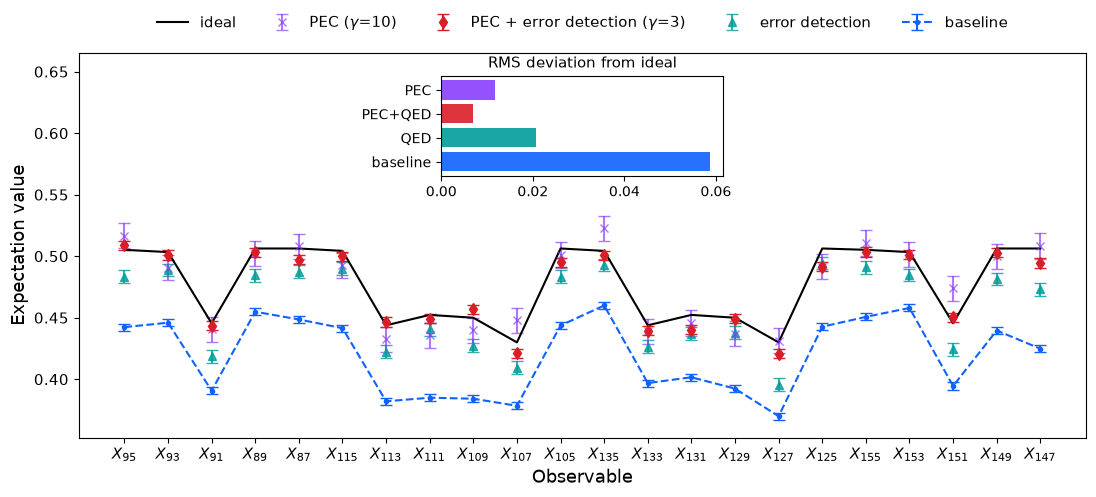

In [10]:
from qiskit.quantum_info import SparsePauliOp
from qiskit_mitigation.utils import executor_expectation_values

mit = np.load(mit_file)
gamma, gamma_post = mit["gammas"]
basis_map = {Pauli("X" * n_data): [SparsePauliOp(o) for o in observables]}
rescale = dict(zip(observables, mit["trex_rescale"], strict=True))


def evs(bits, basis_map, **kwargs):
    """Per-site (means, standard errors) from boolean shot data `bits` of shape (rands, 1, shots, n_data)."""
    out = executor_expectation_values(bits, basis_map, None, avg_axis=(0, 1), **kwargs)
    return np.array([m for m, _ in out]).ravel(), np.sqrt([v for _, v in out]).ravel()


def unpack(mit, prefix, n_data):
    """Restore `mit[f"data_{prefix}"]` from packed bytes to booleans of shape (rands, 1, shots, n_data)."""
    return np.unpackbits(mit[f"data_{prefix}"], axis=-1)[..., :n_data].astype(bool)


unmit_tw, unmit_tw_err = evs(mit["data_tw"], basis_map, measurement_flips=mit["flips_tw"])
ed_tw, ed_tw_err = evs(
    mit["data_tw"],
    basis_map,
    measurement_flips=mit["flips_tw"],
    postselect_mask=mit["mask_tw"],
    rescale_factors=rescale,
)
post, post_err = evs(
    unpack(mit, "post", n_data),
    basis_map,
    measurement_flips=mit["flips_post"],
    pauli_signs=mit["signs_post"],
    postselect_mask=mit["mask_post"],
    rescale_factors=rescale,
)
pec, pec_err = evs(
    unpack(mit, "van", n_data),
    basis_map,
    measurement_flips=mit["flips_van"],
    pauli_signs=mit["signs_van"],
    postselect_mask=mit["mask_van"],
    rescale_factors=rescale,
)

# effective ED+PEC overhead measured from the data: accepted shots per signed accepted shot
signs_post = 1 - 2 * (np.squeeze(mit["signs_post"]).sum(axis=-1) % 2)
gamma_eff = mit["mask_post"].sum() / (signs_post * np.squeeze(mit["mask_post"]).sum(axis=-1)).sum()

print(
    f"gamma PEC {gamma:.2f} | gamma QED+PEC {gamma_post:.2f} (model) / {gamma_eff:.2f} (data) | "
    f"QED survival {mit['mask_tw'].mean():.3f} | QED+PEC survival {mit['mask_post'].mean():.3f} | "
    f"mean QED+PEC err {post_err.mean():.4f}"
)
viz.plot_final(
    obs_exact,
    (unmit_tw, unmit_tw_err),
    (ed_tw, ed_tw_err),
    (pec, pec_err),
    (post, post_err),
    (gamma, gamma_post),
    viz.x_labels(layout, n_data),
    "",
)

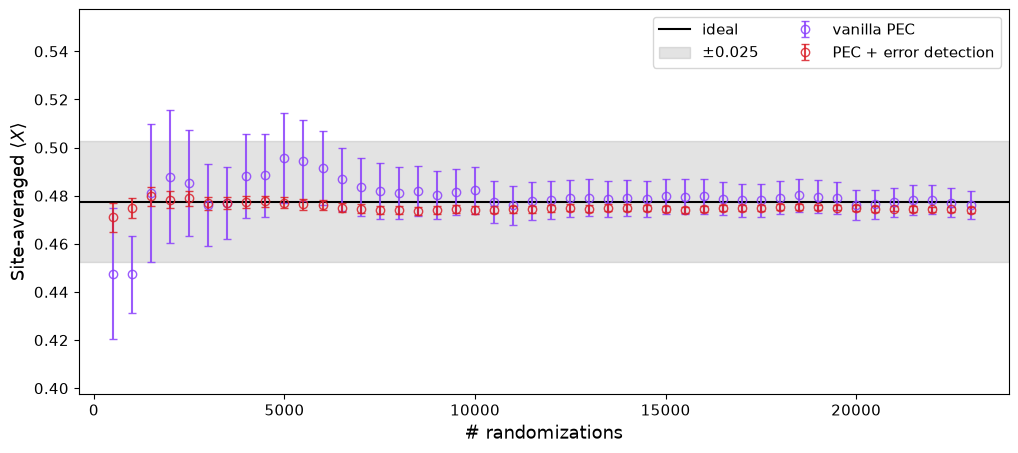

In [11]:
viz.plot_convergence(np.load(mit_file), obs_exact, n_data)